<a href="https://colab.research.google.com/github/d1mene/KAN-Neural-Network-Practice/blob/master/KAN_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install pykan

In [15]:
import torch

In [20]:
torch.set_default_dtype(torch.float64)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

from kan import *
model = KAN(width=[2,5,1], grid=5, k=3, seed=0, device=device)

cuda
checkpoint directory created: ./model
saving model version 0.0


In [21]:
from kan.utils import create_dataset

f = lambda x: torch.exp(torch.sin(torch.pi * x[:, [0]]) + x[:, [1]]**2)
dataset = create_dataset(f, n_var=2, device=device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

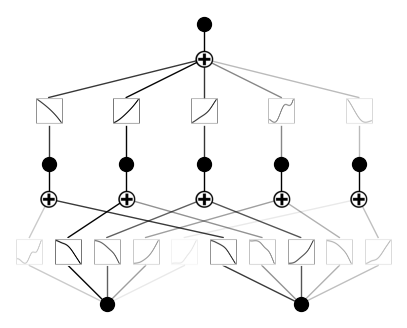

In [22]:
model(dataset['train_input'])
model.plot()

In [23]:
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001)

| train_loss: 1.29e-02 | test_loss: 1.24e-02 | reg: 8.18e+00 | : 100%|█| 50/50 [00:24<00:00,  2.07it

saving model version 0.1


{'train_loss': [array(0.12438341),
  array(0.04477752),
  array(0.02952097),
  array(0.02276274),
  array(0.02199061),
  array(0.02303522),
  array(0.02230119),
  array(0.02379769),
  array(0.02050206),
  array(0.0213029),
  array(0.01950241),
  array(0.01620267),
  array(0.01327078),
  array(0.01212766),
  array(0.01160559),
  array(0.01056838),
  array(0.00962543),
  array(0.01174974),
  array(0.01326356),
  array(0.01182941),
  array(0.01195993),
  array(0.01168119),
  array(0.01111902),
  array(0.01090095),
  array(0.01154105),
  array(0.01213922),
  array(0.01292539),
  array(0.01286828),
  array(0.01308121),
  array(0.01519008),
  array(0.01615797),
  array(0.01683365),
  array(0.01641878),
  array(0.01519725),
  array(0.01486722),
  array(0.01450079),
  array(0.01426445),
  array(0.01415652),
  array(0.01395977),
  array(0.01386367),
  array(0.01369616),
  array(0.01342466),
  array(0.01315458),
  array(0.01292971),
  array(0.01306766),
  array(0.01328558),
  array(0.0137793),
 

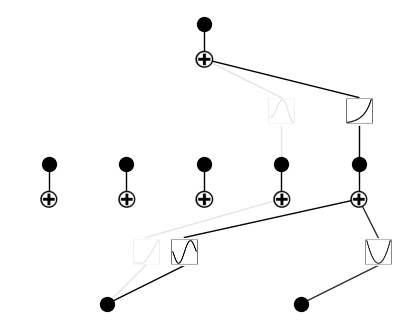

In [24]:
model.plot()

saving model version 0.2


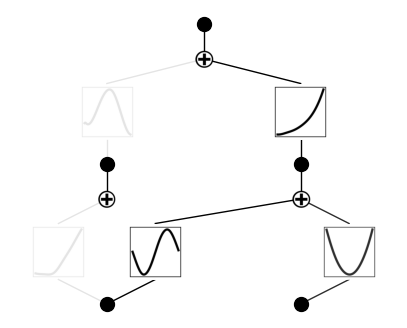

In [25]:
model = model.prune()
model.plot()

In [26]:
model.fit(dataset, opt="LBFGS", steps=50)

| train_loss: 3.56e-03 | test_loss: 3.59e-03 | reg: 9.54e+00 | : 100%|█| 50/50 [00:12<00:00,  3.93it

saving model version 0.3


{'train_loss': [array(0.04210726),
  array(0.016434),
  array(0.00955997),
  array(0.00787684),
  array(0.00752839),
  array(0.0068749),
  array(0.00634265),
  array(0.00587235),
  array(0.00566609),
  array(0.00552951),
  array(0.00542559),
  array(0.00532786),
  array(0.00525131),
  array(0.0051481),
  array(0.0050427),
  array(0.00499073),
  array(0.00484813),
  array(0.00473613),
  array(0.00465447),
  array(0.00455054),
  array(0.00448748),
  array(0.00444446),
  array(0.00436477),
  array(0.00430316),
  array(0.00418539),
  array(0.00418034),
  array(0.00408634),
  array(0.00396272),
  array(0.00392729),
  array(0.00389923),
  array(0.003947),
  array(0.00390942),
  array(0.00387661),
  array(0.00383362),
  array(0.00380316),
  array(0.0039354),
  array(0.00386921),
  array(0.00377803),
  array(0.003639),
  array(0.00356066),
  array(0.00377885),
  array(0.00374514),
  array(0.00371893),
  array(0.00365597),
  array(0.00361933),
  array(0.00362456),
  array(0.00361635),
  array(0

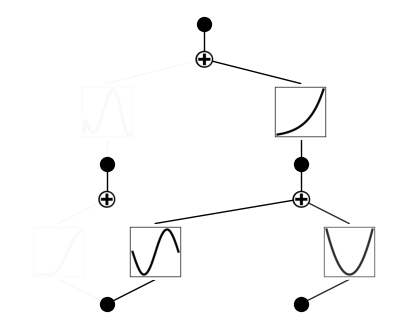

In [27]:
model.plot()

In [28]:
model.refine(10)

saving model version 0.4


MultKAN(
  (act_fun): ModuleList(
    (0-1): 2 x KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
  (symbolic_fun): ModuleList(
    (0-1): 2 x Symbolic_KANLayer()
  )
)

In [29]:
mode = "auto" #"manual"

if mode == "manual":
  model.fix_symbolic(0, 0, 0, 'sin')
  model.fix_symbolic(0, 1, 0, 'x^2')
  model.fix_symbolic(1, 0, 0, 'exp')
elif mode == "auto":
  lib = ['x', 'x^2', 'x^3', 'exp', 'log', 'sqrt', 'tanh', 'sin', 'cos', 'abs']
  model.auto_symbolic(lib=lib)


fixing (0,0,0) with x, r2=0.851436311841431, c=1
fixing (0,0,1) with sin, r2=0.9999641117204013, c=2
fixing (0,1,0) with 0
fixing (0,1,1) with x^2, r2=0.9999922155739617, c=2
fixing (1,0,0) with x, r2=0.1738780036690059, c=1
fixing (1,1,0) with exp, r2=0.9999952029848956, c=2
saving model version 0.5


In [30]:
model.fit(dataset, opt="LBFGS", steps=50);

| train_loss: 2.22e-10 | test_loss: 2.13e-10 | reg: 0.00e+00 | : 100%|█| 50/50 [00:06<00:00,  8.07it

saving model version 0.6


In [31]:
from kan.utils import ex_round

ex_round(model.symbolic_formula()[0][0],4)

/usr/local/lib/python3.12/dist-packages/sympy/core/sympify.py:475: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return sympify(float(a))


1.0*exp(1.00002288765467*x_2**2 + 1.0*sin(3.1416*x_1))

In [32]:
model.symbolic_formula()

([6.21747318475684e-10*x_1 + 0.999999999784569*exp(0.010000000007029*(2.03963466091206e-11 - 9.99999999735542*x_2)**2 + 0.999999999899082*sin(3.14159265375225*x_1 + 6.29708825459442e-11)) + 3.74789102530748e-10],
 [x_1, x_2])